# Coordinate transform illustration

This notebook illustrates the coordinate transform from phase space to pattern-duration space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../')
from src.utils import savefig, subplot_title, get_line_props, set_mpl_style
set_mpl_style()

In [2]:
def Phi(xs, ys):
    return (xs / (xs + ys), xs + ys)

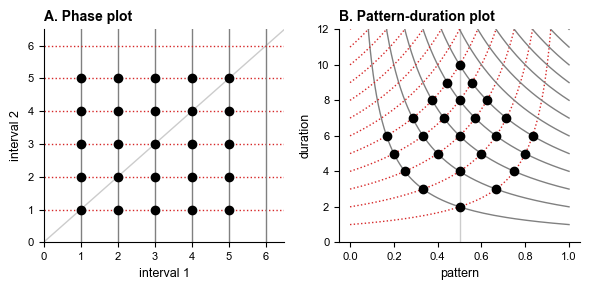

In [3]:
xs = np.linspace(0, 20, 500)
ys = np.linspace(0, 20, 500)
ks = np.arange(1, 20)
ls = np.arange(1, 6)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(6,3))

for k in ks:
    l1, = ax1.plot(k * np.ones(ys.shape), ys, c='0.5', lw=1)
    ax2.plot(*Phi(k*np.ones(ys.shape), ys), **get_line_props(l1))

    l2, = ax1.plot(xs, k * np.ones(ys.shape), ls=":", c='C3', lw=1)
    ax2.plot(*Phi(xs, k*np.ones(xs.shape)), **get_line_props(l2))
    
    if k <= ls.max():
        ax1.plot(k * np.ones(ls.shape), ls, 'ok', zorder=10)
        ax2.plot(*Phi(k, ls), 'ok', zorder=10)

subplot_title(0, 'Phase plot', ax=ax1)
ax1.set_xlabel('interval 1')
ax1.set_ylabel('interval 2')
ax1.set_ylim(0, 6.5)
ax1.set_xlim(0, 6.5)
diag, = ax1.plot([0, 10], [0, 10], c='0.8', lw=1, zorder=0)
sns.despine(ax=ax1)

subplot_title(1, 'Pattern-duration plot', ax=ax2)
ax2.set_xlabel('pattern')
ax2.set_ylabel('duration')
ax2.axvline(0.5, **get_line_props(diag))
sns.despine(ax=ax2)
ax2.set_ylim(0, 12)

plt.tight_layout()
savefig('coordinate-transform.pdf', refresh=False)
savefig('coordinate-transform.png', dpi=300, refresh=False)